## Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import pickle
import time

from nltk.tokenize import TweetTokenizer
import nltk

from nltk import Text
from nltk.tokenize import regexp_tokenize
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline

## CountVectorizer

In [4]:
txt = ["He is ::having a great Time, at the park time?",
       "She, unlike most women, is a big player on the park's grass.",
       "she can't be going"]

In [10]:
count_vec = CountVectorizer(stop_words = 'english', analyzer = 'word', ngram_range = (1,1), min_df = 1, max_df = 1.0, max_features = None)

# Transforms the data into a bag of words
count_train = count_vec.fit(txt)
bag_of_words = count_vec.transform(txt)

count_vec.get_feature_names_out()

array(['big', 'going', 'grass', 'great', 'having', 'park', 'player',
       'time', 'unlike', 'women'], dtype=object)

In [13]:
print("Vocabulary Count: {}".format(len(count_train.vocabulary_)))
print("Vocabulary: \n", count_train.vocabulary_)

Vocabulary Count: 10
Vocabulary: 
 {'having': 4, 'great': 3, 'time': 7, 'park': 5, 'unlike': 8, 'women': 9, 'big': 0, 'player': 6, 'grass': 2, 'going': 1}


### N-grams N = 2

In [14]:
count_vec = CountVectorizer(stop_words="english", analyzer='word', 
                            ngram_range=(1, 2), max_df=1.0, min_df=1, max_features=None)

count_train = count_vec.fit(txt)
bag_of_words = count_vec.transform(txt)

print(count_vec.get_feature_names_out())

['big' 'big player' 'going' 'grass' 'great' 'great time' 'having'
 'having great' 'park' 'park grass' 'park time' 'player' 'player park'
 'time' 'time park' 'unlike' 'unlike women' 'women' 'women big']


### Min_df, Max_df, Max_features

In [16]:
count_vec = CountVectorizer(stop_words="english", analyzer='word', 
                            ngram_range=(1, 2), max_df=0.9, min_df=0.3, max_features=5)

count_train = count_vec.fit(txt)
bag_of_words = count_vec.transform(txt)

print(count_vec.get_feature_names_out())

['big' 'park' 'time' 'unlike' 'unlike women']


## TF-IDF Vectorizer

In [18]:
txt1 = ['His smile was not perfect', 'His smile was not not not not perfect', 'she not sang']
tf = TfidfVectorizer(smooth_idf=False, sublinear_tf=False, norm=None, analyzer='word')
txt_fitted = tf.fit(txt1)
txt_transformed = txt_fitted.transform(txt1)
tf.vocabulary_

{'his': 0, 'smile': 5, 'was': 6, 'not': 1, 'perfect': 2, 'she': 4, 'sang': 3}

In [21]:
idf = tf.idf_
print(dict(zip(txt_fitted.get_feature_names_out(), idf)))

{'his': 1.4054651081081644, 'not': 1.0, 'perfect': 1.4054651081081644, 'sang': 2.09861228866811, 'she': 2.09861228866811, 'smile': 1.4054651081081644, 'was': 1.4054651081081644}


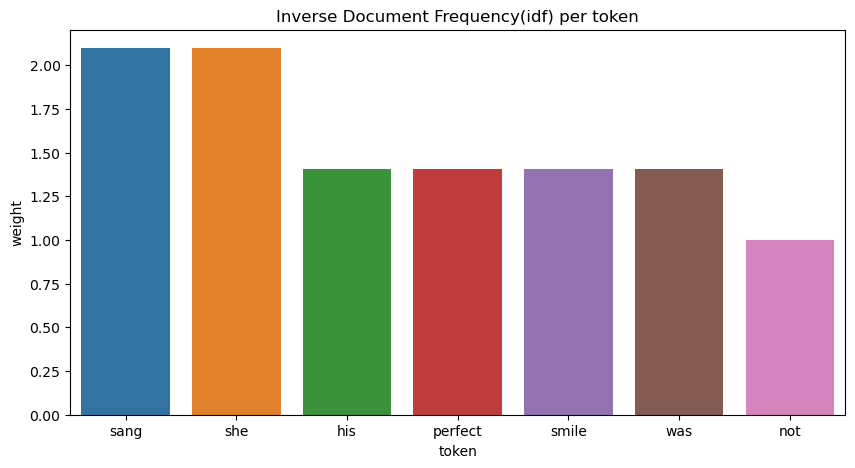

In [25]:
rr = dict(zip(txt_fitted.get_feature_names_out(), idf))

token_weight = pd.DataFrame.from_dict(rr, orient='index').reset_index()
token_weight.columns=('token','weight')
token_weight = token_weight.sort_values(by='weight', ascending=False)
token_weight 

sns.barplot(x='token', y='weight', data=token_weight)            
plt.title("Inverse Document Frequency(idf) per token")
fig=plt.gcf()
fig.set_size_inches(10,5)
plt.show()

In [35]:
feature_names = np.array(tf.get_feature_names_out())
sorted_by_idf = np.argsort(tf.idf_)
print("Features with lowest idf:\n{}".format(
       feature_names[sorted_by_idf[:3]]))
print("\nFeatures with highest idf:\n{}".format(
       feature_names[sorted_by_idf[-3:]]))

Features with lowest idf:
['not' 'his' 'perfect']

Features with highest idf:
['was' 'sang' 'she']


In [36]:
txt_transformed.toarray()[1]

array([1.40546511, 4.        , 1.40546511, 0.        , 0.        ,
       1.40546511, 1.40546511])

In [43]:
# find maximum value for each of the features over all of dataset:
max_val = new1.max(axis=0).toarray().ravel()

#sort weights from smallest to biggest and extract their indices 
sort_by_tfidf = max_val.argsort()

print("Features with lowest tfidf:\n{}".format(
      feature_names[sort_by_tfidf[:3]]))

print("\nFeatures with highest tfidf: \n{}".format(
      feature_names[sort_by_tfidf[-3:]]))

Features with lowest tfidf:
['his' 'perfect' 'smile']

Features with highest tfidf: 
['sang' 'she' 'not']


## Load, Clean, Train, Vectorize, Classify Toxic Comments (w/o parameter tuning)